# Data Exploration — BTC & PAXG (Gold)
5-minute OHLCV klines from Binance

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

DATA = (Path.cwd().parents[1] / "DATA").resolve()
OUT = (Path.cwd().parent / "outputs").resolve()
OUT.mkdir(exist_ok=True)

print(f"DATA: {DATA}")
print(f"OUT:  {OUT}")

DATA: /mnt/c/Users/revno/PROJECTS/CLAUDE/DATA
OUT:  /mnt/c/Users/revno/PROJECTS/CLAUDE/workspace/outputs


## Load Data

In [2]:
def load_data(file):
    cols = ["open_time", "open", "high", "low", "close", "volume"]
    df = pd.read_csv(file, usecols=cols, parse_dates=["open_time"])
    df = df.rename(columns={"open_time": "date"})
    df = df.set_index("date").sort_index()
    return df

btc = load_data(DATA / "BTCUSDT_5m_updated.csv")
paxg = load_data(DATA / "PAXGUSDT_5m_updated.csv")

print(f"BTC:  {len(btc):,} rows | {btc.index.min()} to {btc.index.max()}")
print(f"PAXG: {len(paxg):,} rows | {paxg.index.min()} to {paxg.index.max()}")

BTC:  691,048 rows | 2019-09-09 01:55:00+08:00 to 2026-04-04 13:10:00+08:00
PAXG: 107,361 rows | 2025-03-27 18:30:00+08:00 to 2026-04-04 13:10:00+08:00


## BTC Overview (1h aggregation)

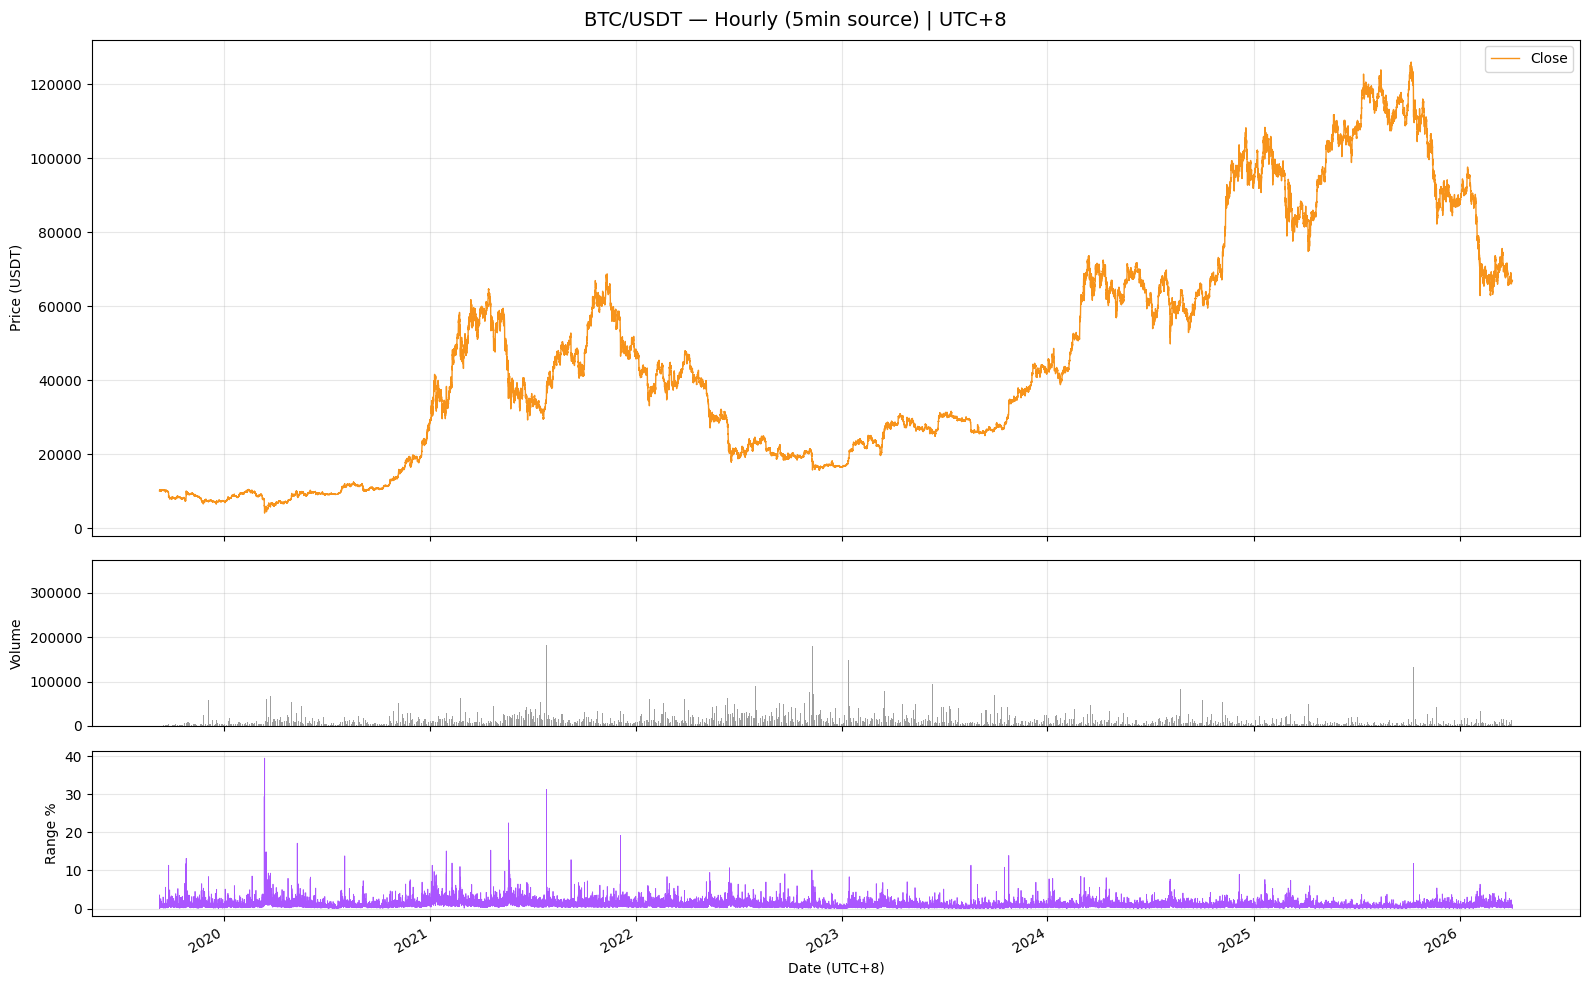

In [3]:
btc_h = btc.resample("1h").agg({"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"})
btc_h.dropna(inplace=True)

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True, gridspec_kw={"height_ratios": [3, 1, 1]})
fig.suptitle("BTC/USDT — Hourly (5min source) | UTC+8", fontsize=14)

axes[0].plot(btc_h.index, btc_h["close"], color="#f7931a", linewidth=1, label="Close")
axes[0].set_ylabel("Price (USDT)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(btc_h.index, btc_h["volume"], color="#777777", width=0.03, alpha=0.7)
axes[1].set_ylabel("Volume")
axes[1].grid(True, alpha=0.3)

axes[2].plot(btc_h.index, (btc_h["high"] - btc_h["low"]) / btc_h["open"] * 100, color="#aa55ff", linewidth=0.6)
axes[2].set_ylabel("Range %")
axes[2].set_xlabel("Date (UTC+8)")
axes[2].grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

out_path = OUT / "btc_overview.png"
fig.savefig(out_path, dpi=120, bbox_inches="tight")
plt.close(fig)

## PAXG/Gold Overview (4h aggregation)

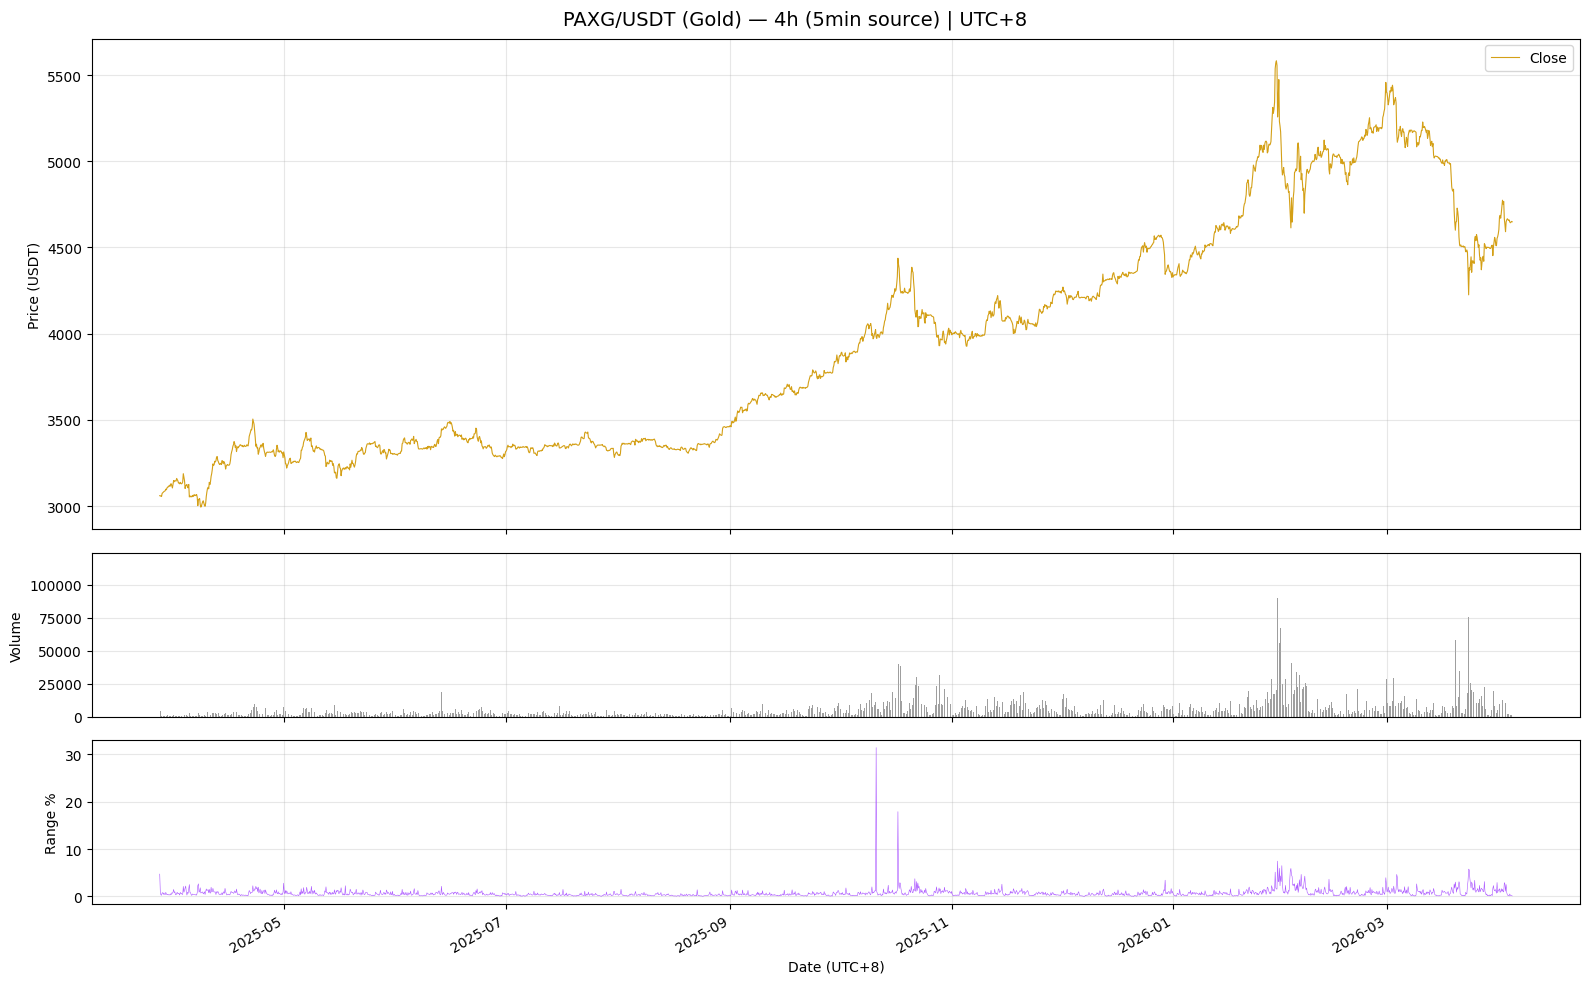

In [4]:
paxg_h = paxg.resample("4h").agg({"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"})
paxg_h.dropna(inplace=True)

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True, gridspec_kw={"height_ratios": [3, 1, 1]})
fig.suptitle("PAXG/USDT (Gold) — 4h (5min source) | UTC+8", fontsize=14)

axes[0].plot(paxg_h.index, paxg_h["close"], color="#d4a017", linewidth=0.8, label="Close")
axes[0].set_ylabel("Price (USDT)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(paxg_h.index, paxg_h["volume"], color="#777777", width=0.1, alpha=0.7)
axes[1].set_ylabel("Volume")
axes[1].grid(True, alpha=0.3)

axes[2].plot(paxg_h.index, (paxg_h["high"] - paxg_h["low"]) / paxg_h["open"] * 100, color="#aa55ff", linewidth=0.4)
axes[2].set_ylabel("Range %")
axes[2].set_xlabel("Date (UTC+8)")
axes[2].grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

out_path = OUT / "paxg_overview.png"
fig.savefig(out_path, dpi=120, bbox_inches="tight")
plt.close(fig)

## Key Statistics

In [5]:
def stats(df, name):
    rng = df.index.max() - df.index.min()
    avg_bar = (df["high"] - df["low"]) / df["open"] * 100
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  Date range:    {df.index.min()} → {df.index.max()}")
    print(f"  Total days:    {rng.days}")
    print(f"  Price range:   {df['close'].min():.2f} — {df['close'].max():.2f}")
    print(f"  Current:       {df['close'].iloc[-1]:.2f}")
    print(f"  Avg bar range: {avg_bar.mean():.3f}%")
    print(f"  Max bar range: {avg_bar.max():.3f}% (on {avg_bar.idxmax()})")
    print(f"  Avg volume:    {df['volume'].mean():,.2f}")
    print(f"  Max volume:    {df['volume'].max():,.2f} (on {df['volume'].idxmax()})")

stats(btc, "BTC/USDT")
stats(paxg, "PAXG/USDT")


  BTC/USDT
  Date range:    2019-09-09 01:55:00+08:00 → 2026-04-04 13:10:00+08:00
  Total days:    2399
  Price range:   3761.10 — 125986.00
  Current:       66850.00
  Avg bar range: 0.236%
  Max bar range: 31.333% (on 2021-07-26 09:00:00+08:00)
  Avg volume:    1,107.87
  Max volume:    86,782.49 (on 2023-10-16 21:25:00+08:00)

  PAXG/USDT
  Date range:    2025-03-27 18:30:00+08:00 → 2026-04-04 13:10:00+08:00
  Total days:    372
  Price range:   2986.21 — 5622.92
  Current:       4649.24
  Avg bar range: 0.085%
  Max bar range: 33.571% (on 2025-10-11 05:20:00+08:00)
  Avg volume:    111.48
  Max volume:    17,378.63 (on 2026-03-23 19:05:00+08:00)


## BTC vs PAXG Return Correlation

In [6]:
common_start = max(btc.index.min(), paxg.index.min())
common_end = min(btc.index.max(), paxg.index.max())
btc_c = btc.loc[common_start:common_end]
paxg_c = paxg.loc[common_start:common_end]
print(f"Overlapping period: {common_start} → {common_end}")
print(f"  BTC bars:  {len(btc_c):,}")
print(f"  PAXG bars: {len(paxg_c):,}")

btc_ret = btc_c["close"].pct_change()
paxg_ret = paxg_c["close"].pct_change()
corr = btc_ret.corr(paxg_ret)
print(f"\n5-min return correlation: {corr:.4f}")

Overlapping period: 2025-03-27 18:30:00+08:00 → 2026-04-04 13:10:00+08:00
  BTC bars:  107,361
  PAXG bars: 107,361

5-min return correlation: 0.2104


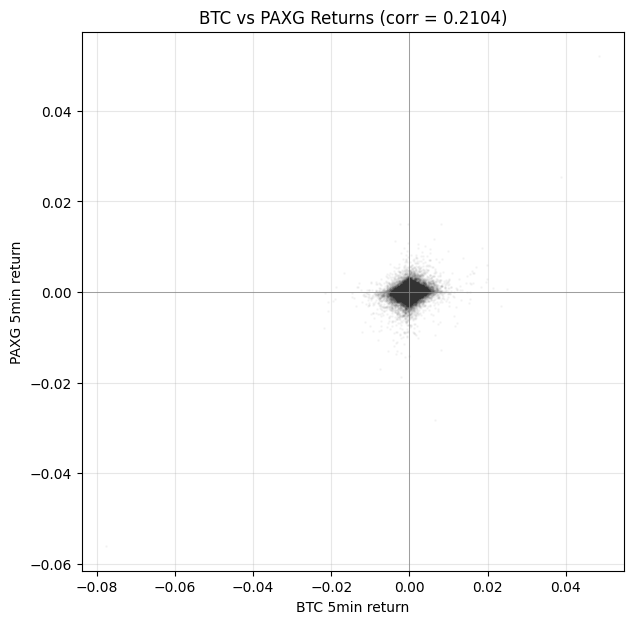

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(btc_ret, paxg_ret, alpha=0.03, s=1, color="#333333")
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("BTC 5min return")
ax.set_ylabel("PAXG 5min return")
ax.set_title(f"BTC vs PAXG Returns (corr = {corr:.4f})")
ax.grid(True, alpha=0.3)
plt.show()

out_path = OUT / "btc_vs_paxg_returns.png"
fig.savefig(out_path, dpi=120, bbox_inches="tight")
plt.close(fig)